Running the pipeline for kidney dataset

In [1]:
import sys
import os
from pathlib import Path

REPO_ROOT = Path("~/scRNA-cross-donor-generalization").expanduser()
os.chdir(REPO_ROOT)
sys.path.append(str(REPO_ROOT / "src"))

from scrna_benchmark.config import DatasetConfig
from scrna_benchmark.pipeline import run_dataset_benchmark

adata_path = "data/kidney/kidney_benchmark_ready.h5ad"

representations = {
    "hvg": "hvg",
    "pca": "X_pca",
    "harmony": "X_harmony",
    "scvi": "X_scVI",
}

config = DatasetConfig(
    dataset_name="kidney_no_batch",
    adata_path=adata_path,
    output_dir="results",

    celltype_col="cell_type",
    donor_col="donor_id",
    batch_col=None,
    group_col="batch",

    representations=representations,

    min_cells=200,
    min_donors=5,

    run_random_split=True,
    run_donor_cv=True,
    run_group_transfer=False,

    run_donor_ablation=True,
    donor_ablation_k_values=[5, 10, 15],
    donor_ablation_n_repeats=5,

    test_size=0.2,
    n_folds=5,
    random_state=42,

    save_filtered_adata=True,
    verbose=True,
)

outputs = run_dataset_benchmark(config)

Running random_split: hvg (hvg)
Running random_split: pca (X_pca)
Running random_split: harmony (X_harmony)
Running random_split: scvi (X_scVI)
Running random_split: hvg (hvg)
Running random_split: pca (X_pca)
Running random_split: harmony (X_harmony)
Running random_split: scvi (X_scVI)
Running random_split: hvg (hvg)
Running random_split: pca (X_pca)
Running random_split: harmony (X_harmony)
Running random_split: scvi (X_scVI)
Running random_split: hvg (hvg)
Running random_split: pca (X_pca)
Running random_split: harmony (X_harmony)
Running random_split: scvi (X_scVI)
Running random_split: hvg (hvg)
Running random_split: pca (X_pca)
Running random_split: harmony (X_harmony)
Running random_split: scvi (X_scVI)
Running donor_cv: hvg (hvg)
Running donor_cv: pca (X_pca)
Running donor_cv: harmony (X_harmony)
Running donor_cv: scvi (X_scVI)

Running donor ablation for hvg (hvg)
  k= 5, repeat=1: macro_f1=0.9788, acc=0.9937
  k= 5, repeat=2: macro_f1=0.9712, acc=0.9889
  k= 5, repeat=3: macr

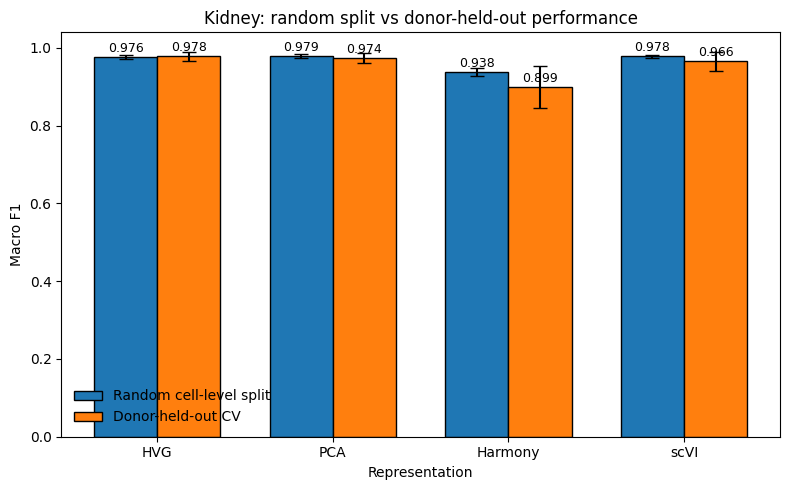

Saved: results/kidney_no_batch/figures/kidney_random_vs_donor_cv.png


In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

result_dir = Path("results/kidney_no_batch")
figures_dir = result_dir / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

rep_order = ["hvg", "pca", "harmony", "scvi"]
rep_labels = {
    "hvg": "HVG",
    "pca": "PCA",
    "harmony": "Harmony",
    "scvi": "scVI",
}

def clean_rep(x):
    return {
        "hvg": "hvg",
        "pca": "pca",
        "harmony": "harmony",
        "scvi": "scvi",
        "X_pca": "pca",
        "X_harmony": "harmony",
        "X_scVI": "scvi",
    }.get(x, x)

def summarize_repeated(df):
    return (
        df.groupby("rep_clean", as_index=False)
        .agg(
            macro_f1_mean=("macro_f1", "mean"),
            macro_f1_std=("macro_f1", "std"),
            accuracy_mean=("accuracy", "mean"),
            accuracy_std=("accuracy", "std"),
        )
    )

random_df = pd.read_csv(result_dir / "random_split" / "random_split_repeated_metrics.csv")
donor_df = pd.read_csv(result_dir / "donor_cv" / "metrics.csv")

random_df["rep_clean"] = random_df["representation"].map(clean_rep)
donor_df["rep_clean"] = donor_df["representation"].map(clean_rep)

random_summary = summarize_repeated(random_df)

common_reps = [
    r for r in rep_order
    if r in set(random_summary["rep_clean"]) and r in set(donor_df["rep_clean"])
]

random_plot = random_summary.set_index("rep_clean").loc[common_reps]
donor_plot = donor_df.set_index("rep_clean").loc[common_reps]

x = np.arange(len(common_reps))
width = 0.36

fig, ax = plt.subplots(figsize=(8, 5))

bars_random = ax.bar(
    x - width / 2,
    random_plot["macro_f1_mean"],
    width,
    yerr=random_plot["macro_f1_std"],
    capsize=5,
    label="Random cell-level split",
    edgecolor="black",
)

bars_donor = ax.bar(
    x + width / 2,
    donor_plot["macro_f1_mean"],
    width,
    yerr=donor_plot["macro_f1_std"],
    capsize=5,
    label="Donor-held-out CV",
    edgecolor="black",
)

ax.set_xticks(x)
ax.set_xticklabels([rep_labels[r] for r in common_reps])
ax.set_xlabel("Representation")
ax.set_ylabel("Macro F1")
ax.set_title("Kidney: random split vs donor-held-out performance")
ax.legend(frameon=False)

for bars in [bars_random, bars_donor]:
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + 0.005,
            f"{h:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

plt.tight_layout()

out_png = figures_dir / "kidney_random_vs_donor_cv.png"
#plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_png)